# Configuração do sistema

In [35]:
!pip install spacy
!python -m spacy download pt_core_news_sm
import pandas as pd
import spacy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 36.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
!pip install wordcloud
from wordcloud import WordCloud


# 1. Preparação do Modelo e Dataset

## 1.1 Carregar o modelo de português

In [38]:
import kagglehub

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")


print("Path to dataset files", path)
nlp = spacy.load("pt_core_news_sm")


Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files /kaggle/input/brazilian-ecommerce


In [39]:
df = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv")

In [40]:
df.shape
df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


## 1.2 Limpeza dos Dados

In [42]:
df.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [43]:
df['review_comment_message'] = df['review_comment_message'].fillna('')

In [44]:
df['review_comment_title'] = df['review_comment_title'].fillna('Sem titulo')

In [45]:
df.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,0
review_comment_message,0
review_creation_date,0
review_answer_timestamp,0


# 2. Tokenização

In [46]:
df['doc'] = list(nlp.pipe(df['review_comment_message']))

# 3. Normalização

## 3.1 Lowercase



In [47]:
df['lowercase_tokens'] = df['doc'].apply(lambda doc: [token.lower_ for token in doc])

##3.1 Remoção de pontuação

In [48]:
df['tokens_sem_pontuacao'] = df['doc'].apply(lambda doc: [token.lower_ for token in doc if not token.is_punct])

## 3.2 Remoção de URLs

In [49]:
df['tokens_sem_url'] = df['doc'].apply(lambda doc: [token.lower_ for token in doc if not (token.like_url and token.is_punct)])

In [50]:
print(df['tokens_sem_url' ])

0                                                       []
1                                                       []
2                                                       []
3           [recebi, bem, antes, do, prazo, estipulado, .]
4        [parabéns, lojas, lannister, adorei, comprar, ...
                               ...                        
99219                                                   []
99220                                                   []
99221    [excelente, mochila, ,, entrega, super, rápida...
99222                                                   []
99223    [meu, produto, chegou, e, ja, tenho, que, devo...
Name: tokens_sem_url, Length: 99224, dtype: object


## 3.3 Remoção de Números

In [51]:
df['tokens_sem_numero'] = df['doc'].apply(lambda doc: [token.lower_ for token in doc if not (token.like_num or token.like_url or token.is_punct)])

# 4 Remoção de stopwords

In [52]:
df['tokens_sem_stopwords'] = df['doc'].apply(lambda doc: [token.lower_ for token in doc if not (token.is_stop or token.is_punct or token.like_num or token.like_url)])


print(df['tokens_sem_stopwords'])

0                                                       []
1                                                       []
2                                                       []
3                              [recebi, prazo, estipulado]
4        [parabéns, lojas, lannister, adorei, comprar, ...
                               ...                        
99219                                                   []
99220                                                   []
99221    [excelente, mochila, entrega, super, rápida, s...
99222                                                   []
99223    [produto, chegou, ja, devolver, defeito, segur...
Name: tokens_sem_stopwords, Length: 99224, dtype: object


# 5. Lematização

In [53]:
df['lemmas'] = df['doc'].apply(lambda doc: [token.lemma_ for token in doc if not (token.is_stop or token.is_punct or token.like_num or token.like_url)])

# 6. Analisar comprimento dos textos

In [54]:
df['tamanhos_textos'] = df['lemmas'].apply(len)


/tmp/ipykernel_39393/2576289895.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Review Score')


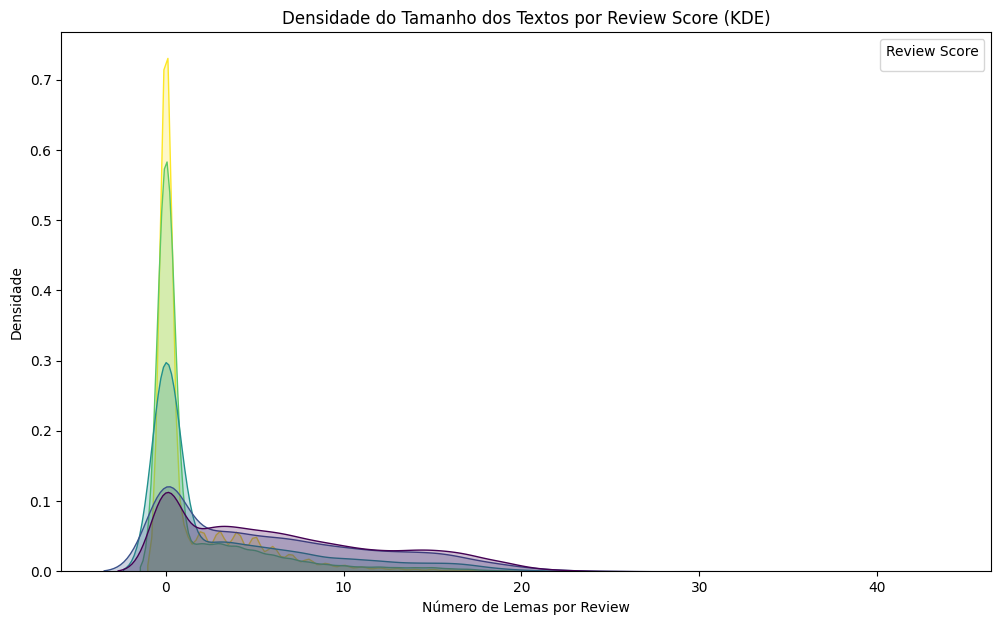

In [55]:
plt.figure(figsize=(12, 7))
sns.kdeplot(data=df, x='tamanhos_textos', hue='review_score', fill=True, common_norm=False, palette='viridis')
plt.title('Densidade do Tamanho dos Textos por Review Score (KDE)')
plt.xlabel('Número de Lemas por Review')
plt.ylabel('Densidade')
plt.legend(title='Review Score')
plt.show()

## 6.1 A maioria dos textos é curto

## 6.2 A maioria dos textos que tem alto score são curtos, mas mais frequentes. Enquanto para avaliações negativas, se usa mais palavras

# 7. Palavras mais frequentes

In [56]:
from collections import Counter

# Achatar a lista de lemmas de todas as reviews
all_lemmas = [lemma for sublist in df['lemmas'] for lemma in sublist]

# Calcular a frequência de todos os lemmas
overall_word_frequencies = Counter(all_lemmas)

# Exibir as 20 palavras mais comuns
print('As 20 palavras mais comuns em todas as reviews:')
for word, count in overall_word_frequencies.most_common(20):
    print(f'- {word}: {count}')

As 20 palavras mais comuns em todas as reviews:
- produto: 16604
- prazo: 8244
- chegar: 6219
- entregar: 5946
- entrega: 5109
- 
: 4451
- recebi: 3074
- vir: 3020
- qualidade: 2684
- loja: 2385
- compra: 2361
- Produto: 2350
- rápido: 2245
- dia: 2135
- excelente: 1773
- recomendar: 1454
- comprar: 1357
- Recebi: 1339
- recomendo: 1323
- esperar: 1279


In [57]:
from collections import Counter

raw_tokens = []
for doc in nlp.pipe(df['review_comment_message']):
    raw_tokens.extend([token.text.lower() for token in doc if not token.is_space and token.text.strip() != ''])

overall_raw_word_frequencies = Counter(raw_tokens)

print('As 10 palavras mais comuns no corpus bruto (sem pré-processamento):')
dictio = {}
for word, count in overall_raw_word_frequencies.most_common(10):
    print(f'- {word}: {count}')

As 10 palavras mais comuns no corpus bruto (sem pré-processamento):
- .: 29874
- ,: 22213
- o: 18783
- produto: 18380
- e: 15763
- a: 12217
- de: 11316
- do: 11146
- não: 10769
- !: 10416


/tmp/ipykernel_39393/522846757.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=words, y=counts, palette='viridis')


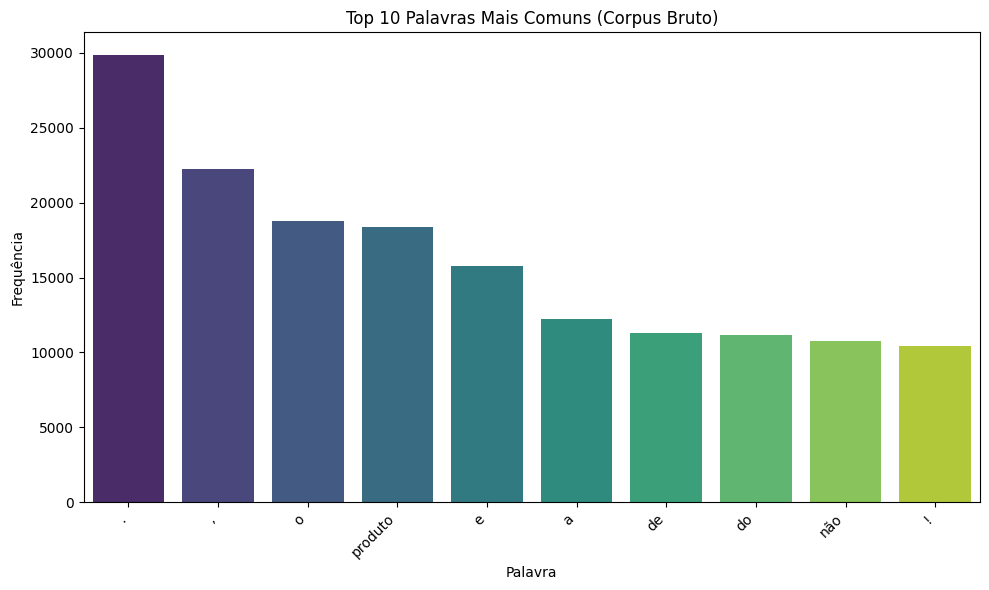

In [58]:
top_10_words = overall_raw_word_frequencies.most_common(10)
words = [item[0] for item in top_10_words]
counts = [item[1] for item in top_10_words]

plt.figure(figsize=(10, 6))
sns.barplot(x=words, y=counts, palette='viridis')
plt.title('Top 10 Palavras Mais Comuns (Corpus Bruto)')
plt.xlabel('Palavra')
plt.ylabel('Frequência')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7.1 A remoção de stopwords mudou de maneira que tem mais conteúdo para analisar em vez de pontos e virgulas

## 7.2 produto, recomendo, entrega, esperar indicam temas das reviews

## 7.3 Aparece com mais destaque a palavra produto






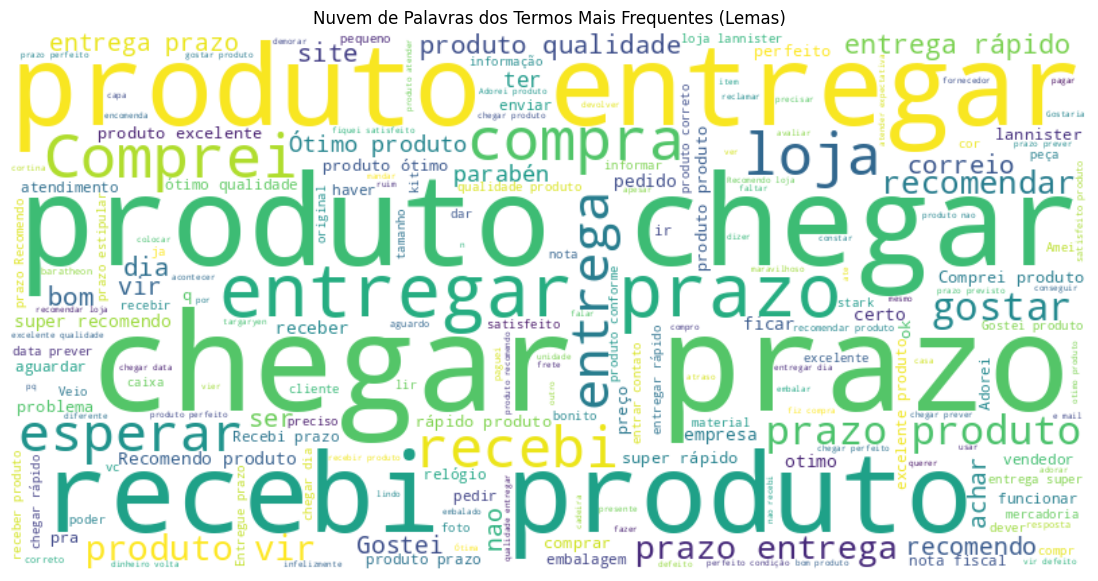

In [59]:
text = " ".join(all_lemmas)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras dos Termos Mais Frequentes (Lemas)')
plt.show()

# 8. Frequência de palavras por classe

#

In [60]:
negative_reviews = df[df['review_score'].isin([1, 2])]
positive_reviews = df[df['review_score'].isin([4, 5])]

all_lemmas_negative = [lemma for sublist in negative_reviews['lemmas'] for lemma in sublist if lemma.strip() != '']

all_lemmas_positive = [lemma for sublist in positive_reviews['lemmas'] for lemma in sublist if lemma.strip() != '']

word_frequencies_negative = Counter(all_lemmas_negative)

word_frequencies_positive = Counter(all_lemmas_positive)

print('As 20 palavras mais comuns em reviews NEGATIVAS:')
for word, count in word_frequencies_negative.most_common(20):
    print(f'- {word}: {count}')

print('\nAs 20 palavras mais comuns em reviews POSITIVAS:')
for word, count in word_frequencies_positive.most_common(20):
    print(f'- {word}: {count}')

As 20 palavras mais comuns em reviews NEGATIVAS:
- produto: 6017
- recebi: 2247
- entregar: 2015
- chegar: 1501
- vir: 1459
- entrega: 1254
- dia: 1133
- Comprei: 956
- compra: 906
- prazo: 895
- nao: 822
- loja: 803
- pedido: 680
- comprei: 656
- receber: 569
- ser: 527
- site: 500
- lannister: 492
- correio: 476
- contato: 453

As 20 palavras mais comuns em reviews POSITIVAS:
- produto: 9041
- prazo: 6878
- chegar: 4245
- entregar: 3476
- entrega: 3431
- rápido: 2096
- qualidade: 2091
- Produto: 1824
- excelente: 1734
- loja: 1404
- compra: 1268
- recomendo: 1249
- Recomendo: 1243
- perfeito: 1197
- super: 1139
- vir: 1054
- recomendar: 1049
- satisfeito: 927
- bom: 889
- Gostei: 877


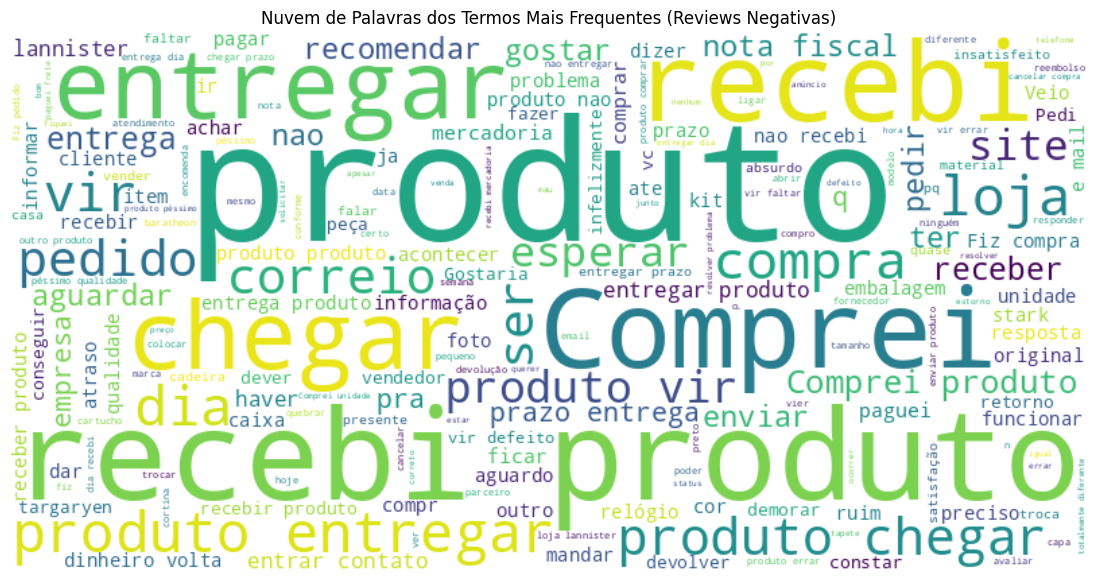

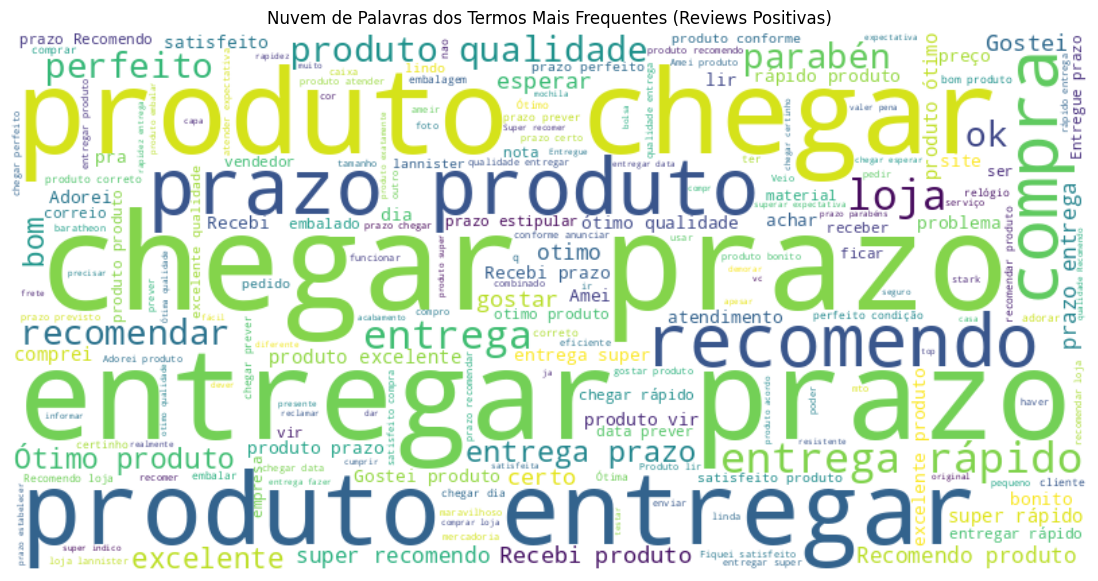

In [61]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

text_negative = " ".join(all_lemmas_negative)
wordcloud_negative = WordCloud(width=800, height=400, background_color='white').generate(text_negative)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras dos Termos Mais Frequentes (Reviews Negativas)')
plt.show()

text_positive = " ".join(all_lemmas_positive)
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(text_positive)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras dos Termos Mais Frequentes (Reviews Positivas)')
plt.show()